<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Python_chapter2_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### １次元のクラスタリング

以下のような１次元データを考えます。

In [0]:
data = [-4.3, -3.1, -0.5, 0.0, 3.8, 5.3]
mu_c = 2.0 ## mu candidate

図にしてみましょう。  
(とりあえず細かいことは置いといて、以下のコードを実行してください)

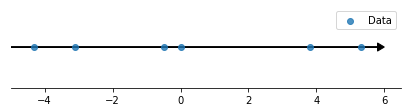

In [0]:
import numpy as np ## numpyというライブラリをインポートしてnpという名前で使う
data = np.array([-4.3, -3.1, -0.5, 0.0, 3.8, 5.3])
from matplotlib import pyplot as plt 
fig = plt.figure(figsize=(7,1.5))
ax = fig.add_subplot(1,1,1)
ax.set_xlim([-5,6.5]);ax.set_ylim([-0.5,0.5])
ax.arrow(x=-5,y=0,dx=11,dy=0,width=0.0001,head_width=0.1,head_length=0.2,length_includes_head=True,color='k')
ax.spines["right"].set_color("none") # 右消し                                                                                                                                                                                    
ax.spines["left"].set_color("none")  # 左消し                                                                                                                                                                                    
ax.spines["top"].set_color("none")  # 上消し                                                                                                                                                                                    
ax.scatter(data,0*data,label="Data",alpha=0.8,zorder=3000)
ax.set_yticks([])
ax.legend()
plt.show()
plt.close()



これを3つのクラスターに分類せよと言われれば簡単でしょう。  

ただ、一般のデータではそう簡単には行きませんので、講義でならったように、  
距離の二乗和を計算するコードを書いてみましょう。

まずは簡単のため、クラスターの数が1個として、
クラスターの中心を2.0にとってみます。   

6つのデータそれぞれと2.0との距離は以下のように計算できます

In [0]:
data = [-4.3, -3.1, -0.5, 0.0, 3.8, 5.3] ## 念の為再定義
total = 0.0 ## 二乗和の値を足していく変数を定義
mu_c = 2.0 
for tmp in data:
  total += (tmp-mu_c)**2
print(total)


90.07999999999998


**補足**  
numpyライブラリを使うと、上のコードは

In [0]:
import numpy as np
data = np.array([-4.3, -3.1, -0.5, 0.0, 3.8, 5.3])
mu_c = 2.0 
total = np.sum( (data-mu_c)**2 )
print(total)

90.07999999999998


と簡略化できます。 data-mu_cでは、各要素からmu_cを引いたndarrayが作成され  

sum関数で、要素の全合計を計算します　

---




クラスターの割当が決まっている場合、距離の二乗和を最小化する点は、  
同一のクラスターに所属するデータの平均値に一致します。  
データの平均値を取得して、二乗和を計算してみます。

In [0]:
mu = np.mean(np.array(data))
total = 0.0 ## 値の初期化
for tmp in data:
  total += (tmp-mu)**2
print(total)

70.63999999999999


これまでのデータを3つのクラスターに分類したい場合も同様に距離の二乗和を計算します。  
ただし、クラスターの数がK個あるときは、K個のクラスター中心を定義しなければなりませんし、それぞれのデータがどのクラスターに所属しているかという情報も必要です。


  


In [0]:
data= [ np.array([-4.3, -3.1]), np.array([-0.5, 0.0]), np.array([3.8, 5.3]) ]
mu = np.array([-3.7, -0.25, 4.55])
total = 0.0
for knum in range(3):
  total += np.sum( (data[knum] - mu[knum])**2 )
print(total)

1.9699999999999998


これまで考察してきたものは「予めクラスターの割当が決まっている場合」
でした。  
ただし、一般の場合にはクラスターの割当を変えながら検証することが必要なので、
クラスターの割当を指定するインデックスを含んだものとしてデータを定義しなければなりません。

In [0]:
data = np.array( [ [-4.3,2],[-3.1,1],
                  [-0.5,2], [0.0,0],
                  [3.8,0], [5.3,1] ]) 
mu_c = np.array([-3.7, -0.25, 4.55])

実際には入れ子になっているリストの2番目(クラスターの割当)と、mu_cをあれこれ変えながら、
最小の[距離の二乗和]を考える必要がありますが、  
講義でも話した通り、こうした最適化問題を解くのは一般に難しく、  
また、様々な最適化手法を包括的に学ぶのは、講義の１コマでは不可能です。

以下では、最適化を行う部分はライブラリに丸投げすることにして、  
[とりあえずクラスタリングができるようになる]というのをひとまずのゴールとしましょう。  




#### Scipyライブラリを用いたK-means クラスタリング

### 補足
###### 特殊な形状のデータ


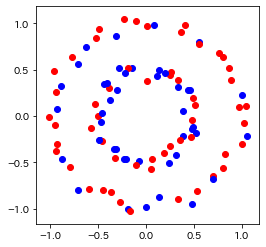

In [0]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans

N =100
noise=0.05
xy,z = make_circles(n_samples=N, factor=.5, noise=noise)

knum=2
km_model= KMeans(n_clusters=knum, init='k-means++', n_init=10, max_iter=300,
                 tol=0.0001,precompute_distances='auto', verbose=0,
                 random_state=None, copy_x=True, n_jobs=1).fit(xy.reshape(-1,1))
km_l = km_model.labels_

cols=["red","blue","green"]

plt.figure(figsize=(4,4)) 
for i, tmp in enumerate(xy):
    plt.scatter(xy[i][0],xy[i][1],color=cols[km_l[i]])
plt.show()
plt.close()


このように、特殊な形状な場合のクラスタリングにはK-means法は一般に有効ではなく、Spectral Clusteringなどの手法が必要です。